<a href="https://colab.research.google.com/github/katnicole14/Multilevel_Thresholding_COS791/blob/Otsu/ImageProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Packages

# New Section

In [ ]:
!pip install pillow

#Configurations



In [ ]:
from pathlib import Path
from typing import Iterator, Tuple


import math

import numpy as np
from PIL import Image

DATA PREPERATION
1. loading the dataset(Images)
2. Converting the images to greyscale
3. Doing a histogram


In [ ]:
#Method for loading a grey scale

def load_grayscale(path: Path) -> np.ndarray:
    """
    Load an image file and convert it to 8-bit grayscale.

    Uses PIL's 'L' mode conversion, which applies the standard
    ITU-R 601-2 luma transform:
        L = 0.299*R + 0.587*G + 0.114*B
    Any alpha channel is dropped automatically by first forcing RGB.
    """
    img = Image.open(path).convert("RGB")   # drop alpha if present
    img = img.convert("L")                  # RGB -> grayscale, uint8
    return np.array(img, dtype=np.uint8)

#METHOD FOR IMPLEMENTING THE HISTOGRAM BASED ON THE FORMULA GIVEM
def build_histogram(gray: np.ndarray, levels: int = 256) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build the raw histogram h(i) and the normalised probability
    distribution p_i = h(i) / (M*N) used by Otsu/Kapur/Tsallis.
    """
    hist, _ = np.histogram(gray.ravel(), bins=levels, range=(0, levels))
    pdf = hist.astype(np.float64) / gray.size
    return hist, pdf

In [ ]:

def is_ground_truth_file(path: Path) -> bool:
    """BDS500 ground-truth / ground-boundary files are suffixed '_gt'."""
    return path.stem.endswith("_gt")

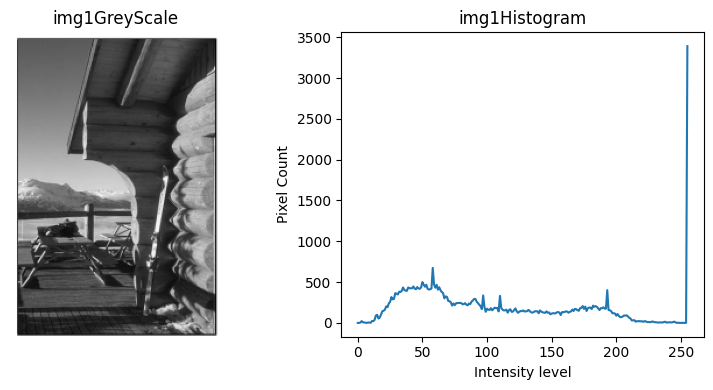

img1       shape=(262, 181)  sum(pdf)=1.0000


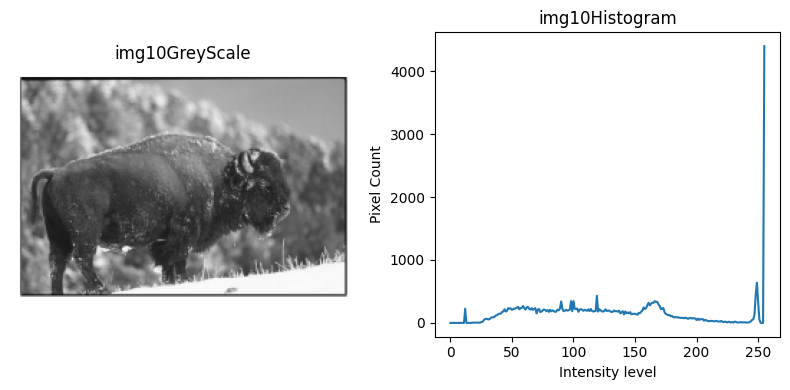

img10      shape=(163, 241)  sum(pdf)=1.0000


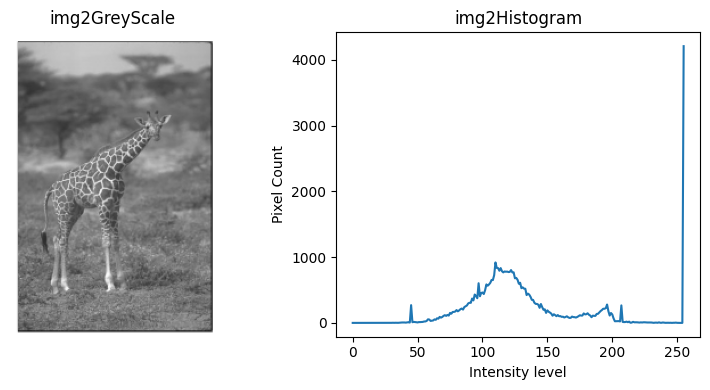

img2       shape=(268, 180)  sum(pdf)=1.0000


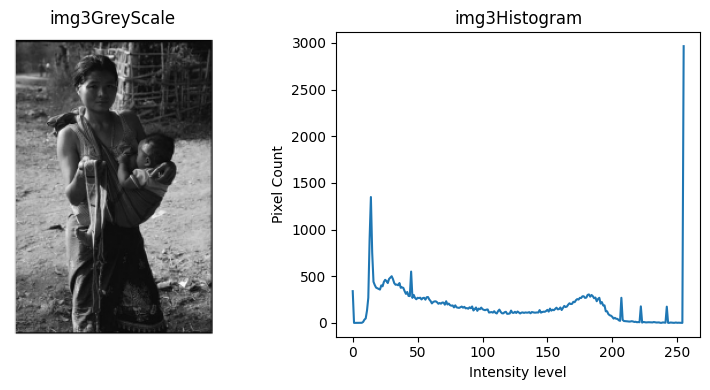

img3       shape=(265, 178)  sum(pdf)=1.0000


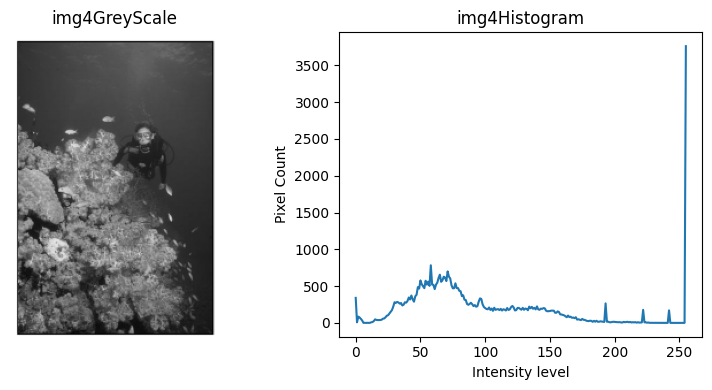

img4       shape=(265, 181)  sum(pdf)=1.0000


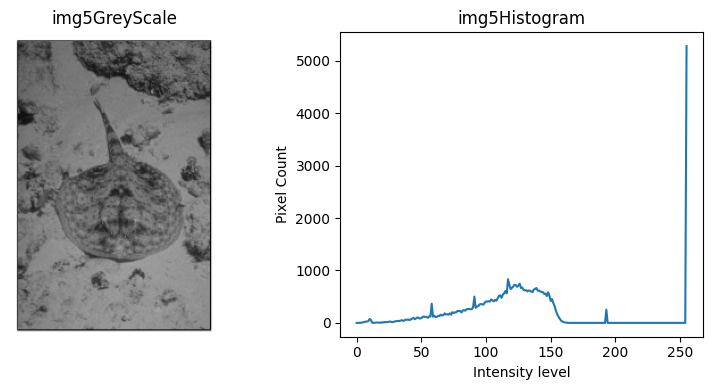

img5       shape=(268, 184)  sum(pdf)=1.0000


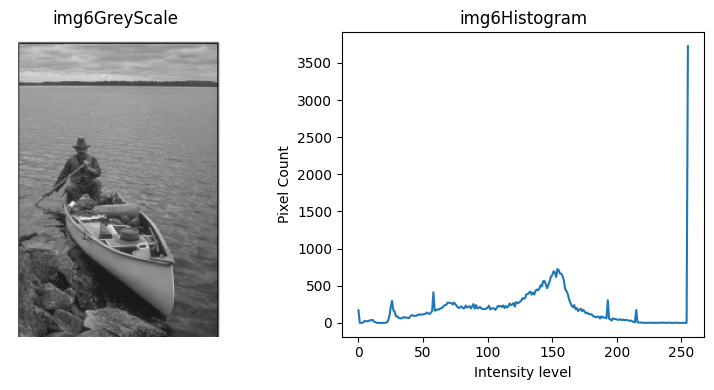

img6       shape=(261, 181)  sum(pdf)=1.0000


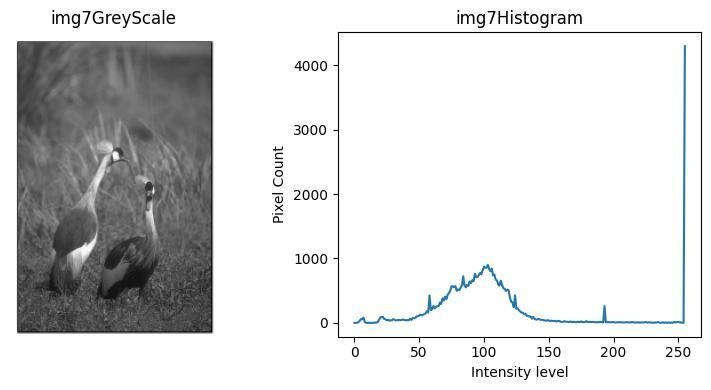

img7       shape=(267, 181)  sum(pdf)=1.0000


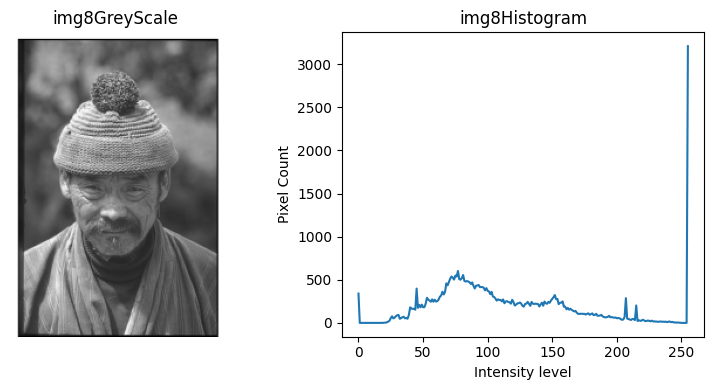

img8       shape=(261, 181)  sum(pdf)=1.0000


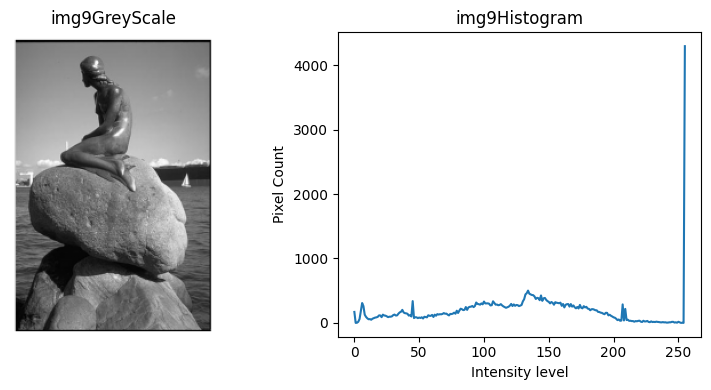

img9       shape=(267, 181)  sum(pdf)=1.0000


In [ ]:
import matplotlib.pyplot as plt

def iter_dataset_images(
    dataset_dir: str,
    pattern: str = "*.png",
) -> Iterator[Tuple[str, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Generator that yields ONE image at a time from a dataset folder,
    skipping any ground-truth ('*_gt.png') files.

    Yields
    ------
    name : str            filename stem, e.g. 'img1'
    gray : np.ndarray     (H, W) uint8 grayscale image
    hist : np.ndarray     (256,) raw histogram counts
    pdf  : np.ndarray     (256,) normalised probability distribution
    """
    folder = Path(dataset_dir)
    files = sorted(
        p for p in folder.glob(pattern) if not is_ground_truth_file(p)
    )

    for path in files:
        gray = load_grayscale(path)
        hist, pdf = build_histogram(gray)
        yield path.stem, gray, hist, pdf


if __name__ == "__main__":
    # Quick sanity check over the BDS500 folder
    for name, gray, hist, pdf in iter_dataset_images("/content/sample_data/BSDS500"):
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(gray, cmap="gray", vmin=0,vmax=255)
        axes[0].set_title(name+"GreyScale")
        axes[0].axis("off")

        axes[1].plot(hist)
        axes[1].set_title(name +"Histogram")
        axes[1].set_xlabel("Intensity level")
        axes[1].set_ylabel("Pixel Count")

        plt.tight_layout()
        plt.show()
        print(f"{name:10s} shape={gray.shape}  sum(pdf)={pdf.sum():.4f}")

#Applying the Objective Functions
1.Otsu
2.Kapur's
3.Tsallis

#Implementing the Otsu
Definition
1. It is a technique based of between-class- variance (non-parametric threshold selection) concept and it identifies the finiest threshold by maximizing the objective value.





In [ ]:
#the threshold values
K= [3,5,7,9,11,12]

#Calculate the cumulative sum Pi{k}=sum(pi) for i in class k
#p(i)= h(i)/(M ×N)
def precompute_cumulative(pdf: np.ndarray):
    """
    Precompute the cumulative zeroth-order (P) and first-order (S)
    moments of the histogram. Call this ONCE per image.

    P[i] = sum_{j=0}^{i} p_j        (cumulative probability)
    S[i] = sum_{j=0}^{i} j * p_j    (cumulative intensity-weighted prob)
    """
    levels = np.arange(len(pdf))
    P = np.cumsum(pdf)
    S = np.cumsum(levels * pdf)
    return P, S


NameError: name 'pdf' is not defined

In [ ]:
def repair_thresholds(t: np.ndarray, L: int = 256) -> np.ndarray:
    """
    Convert a raw DE candidate vector into a valid, strictly increasing,
    duplicate-free set of integer thresholds in [1, L-2].

    This is necessary because DE mutation/crossover produces continuous,
    unordered, possibly out-of-bounds vectors.
    """
    t = np.round(t).astype(int)
    t = np.clip(t, 1, L - 2)
    t = np.unique(t)  # sorts AND removes duplicates

    # If duplicates collapsed the count below K, nudge values apart
    # so downstream code always gets exactly len(original) thresholds.
    K = len(t)
    while len(np.unique(t)) < K:
        # simple repair: push colliding thresholds up by 1 (clipped)
        for i in range(1, len(t)):
            if t[i] <= t[i - 1]:
                t[i] = min(t[i - 1] + 1, L - 2)
    return t


def otsu_fitness(t: np.ndarray, P: np.ndarray, S: np.ndarray, L: int = 256) -> float:
    """
    Compute the between-class variance (sigma_B^2) for a candidate
    threshold vector. This is the value DE should MAXIMIZE.

    t : raw candidate vector from the optimiser (any real values)
    P, S : precomputed cumulative moments from precompute_cumulative()
    """
    thresholds = repair_thresholds(t, L)

    # class boundaries: [0, t1], [t1+1, t2], ..., [tK+1, L-1]
    bounds = np.concatenate(([-1], thresholds, [L - 1]))

    mu_T = S[-1]  # global mean (cumulative sum up to L-1)

    sigma_b2 = 0.0
    for k in range(len(bounds) - 1):
        lo, hi = bounds[k], bounds[k + 1]
        P_lo = P[lo] if lo >= 0 else 0.0
        S_lo = S[lo] if lo >= 0 else 0.0

        omega_k = P[hi] - P_lo
        if omega_k <= 1e-12:
            continue  # empty class, contributes 0 (shouldn't happen post-repair)

        class_sum = S[hi] - S_lo
        mu_k = class_sum / omega_k
        sigma_b2 += omega_k * (mu_k - mu_T) ** 2

    return sigma_b2

# Kapur